In [1]:
import re
import math
import random
import urllib.request

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from functools import partial
from tqdm import tqdm

import matplotlib.pyplot as plt

SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

url = "https://gist.githubusercontent.com/romaklimenko/c95f3a864828f7f034b7a33d1676e420/raw/warandpeace.txt"
filename, _ = urllib.request.urlretrieve(url, "warandpeace.txt")

with open(filename, "r", encoding="utf-8") as f:
    text = f.read()

text = (
    text.replace("ё", "е")
    .replace("Ё", "Е")
    .replace("\xa0", " ")
    .replace("\xad", "")
)

text = re.sub(r" {2,}", " ", text)
text = re.sub(r"\n{3,}", "\n\n", text)

print(f"Длина очищенного текста: {len(text)} символов")


Длина очищенного текста: 1886870 символов


In [2]:
vocab = sorted(set(text))

char_to_id = {char: i for i, char in enumerate(vocab)}
id_to_char = {i: char for i, char in enumerate(vocab)}

vocabulary_size = len(vocab)

print(f"Размер словаря: {vocabulary_size}")
print(f"Символы словаря:\n{vocab}")


Размер словаря: 135
Символы словаря:
['\n', ' ', '!', '"', "'", '(', ')', '*', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'X', '\\', '^', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'А', 'Б', 'В', 'Г', 'Д', 'Е', 'Ж', 'З', 'И', 'Й', 'К', 'Л', 'М', 'Н', 'О', 'П', 'Р', 'С', 'Т', 'У', 'Ф', 'Х', 'Ц', 'Ч', 'Ш', 'Щ', 'Ь', 'Э', 'Ю', 'Я', 'а', 'б', 'в', 'г', 'д', 'е', 'ж', 'з', 'и', 'й', 'к', 'л', 'м', 'н', 'о', 'п', 'р', 'с', 'т', 'у', 'ф', 'х', 'ц', 'ч', 'ш', 'щ', 'ъ', 'ы', 'ь', 'э', 'ю', 'я']


In [3]:
sequence_length = 150
step = 25

full_text_tensor = torch.tensor(
    [char_to_id[c] for c in text],
    dtype=torch.long
)

split_idx = int(len(full_text_tensor) * 0.9)

train_text_tensor = full_text_tensor[:split_idx]
val_text_tensor = full_text_tensor[split_idx:]

print(f"Размер train текста: {len(train_text_tensor):,} символов")
print(f"Размер validation текста: {len(val_text_tensor):,} символов")


def create_sequences(text_tensor, sequence_length, step):
    x = text_tensor[:-1].unfold(dimension=0, size=sequence_length, step=step)
    y = text_tensor[1:].unfold(dimension=0, size=sequence_length, step=step)

    return x, y


x_train, y_train = create_sequences(train_text_tensor, sequence_length, step)
x_val, y_val = create_sequences(val_text_tensor, sequence_length, step)

print(f"\nTrain последовательностей: {x_train.size(0):,}")
print(f"Validation последовательностей: {x_val.size(0):,}")

train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)


Размер train текста: 1,698,183 символов
Размер validation текста: 188,687 символов

Train последовательностей: 67,922
Validation последовательностей: 7,542


In [4]:
class CharLSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=256, hidden_dim=1024,
                 num_layers=2, dropout=0.2):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.rnn = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.rnn(x, hidden)
        out = self.dropout(out)
        logits = self.fc(out)

        return logits, hidden


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Используемое устройство: {device}")

model = CharLSTMModel(
    vocab_size=vocabulary_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=2,
    dropout=0.3
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Количество обучаемых параметров: {num_parameters:,}")


Используемое устройство: cuda
Количество обучаемых параметров: 973,575


In [6]:
epochs = 40

best_val_loss = float("inf")

early_stopping_patience = 5
epochs_without_improvement = 0

history_train_loss = []
history_val_loss = []
history_train_acc = []
history_val_acc = []
history_train_ppl = []
history_val_ppl = []

for epoch in range(epochs):
    model.train()

    train_total_loss = 0.0
    train_correct = 0
    train_total_tokens = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Эпоха {epoch + 1:02d}/{epochs}"
    )

    for x_batch, y_batch in progress_bar:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits, _ = model(x_batch)

        loss = criterion(
            logits.reshape(-1, vocabulary_size),
            y_batch.reshape(-1)
        )
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_total_loss += loss.item()

        preds = torch.argmax(logits, dim=-1)
        train_correct += (preds == y_batch).sum().item()
        train_total_tokens += y_batch.numel()

        batch_acc = (preds == y_batch).float().mean().item() * 100

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{batch_acc:.1f}%"
        )

    avg_train_loss = train_total_loss / len(train_loader)
    train_accuracy = train_correct / train_total_tokens * 100
    train_perplexity = math.exp(avg_train_loss)

    model.eval()

    val_total_loss = 0.0
    val_correct = 0
    val_total_tokens = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits, _ = model(x_batch)

            loss = criterion(
                logits.reshape(-1, vocabulary_size),
                y_batch.reshape(-1)
            )
            val_total_loss += loss.item()

            preds = torch.argmax(logits, dim=-1)
            val_correct += (preds == y_batch).sum().item()
            val_total_tokens += y_batch.numel()

    avg_val_loss = val_total_loss / len(val_loader)
    val_accuracy = val_correct / val_total_tokens * 100
    val_perplexity = math.exp(avg_val_loss)

    history_train_loss.append(avg_train_loss)
    history_val_loss.append(avg_val_loss)
    history_train_acc.append(train_accuracy)
    history_val_acc.append(val_accuracy)
    history_train_ppl.append(train_perplexity)
    history_val_ppl.append(val_perplexity)

    scheduler.step(avg_val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"\nЭпоха {epoch + 1:02d}/{epochs}\n"
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Train PPL: {train_perplexity:.2f}\n"
        f"Val Loss:   {avg_val_loss:.4f} | "
        f"Val Acc:   {val_accuracy:.2f}% | "
        f"Val PPL:   {val_perplexity:.2f}\n"
        f"Learning Rate: {current_lr:.6f}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        checkpoint = {
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
    
            "vocab_size": vocabulary_size,
            "embedding_dim": 128,
            "hidden_dim": 256,
            "num_layers": 2,
            "dropout": 0.3,
    
            "char_to_id": char_to_id,
            "id_to_char": id_to_char,
    
            "epoch": epoch + 1,
            "val_loss": avg_val_loss,
    
            "history_train_loss": history_train_loss,
            "history_val_loss": history_val_loss,
            "history_train_acc": history_train_acc,
            "history_val_acc": history_val_acc,
            "history_train_ppl": history_train_ppl,
            "history_val_ppl": history_val_ppl
        }
        torch.save(checkpoint, "char_rnn_war_and_peace.pt")
        print(
            f"Сохранена лучшая модель "
            f"(Validation Loss: {avg_val_loss:.4f})"
        )
    else:
        epochs_without_improvement += 1
        print(
            f"Нет улучшения Validation Loss "
            f"({epochs_without_improvement}/"
            f"{early_stopping_patience})"
        )
    if epochs_without_improvement >= early_stopping_patience:
        print(
            f"\nValidation Loss не улучшался "
            f"{early_stopping_patience} эпох подряд."
        )
        break

print("\nОбучение завершено")


Эпоха 01/40: 100%|█████████████████████████████████████████| 1062/1062 [00:24<00:00, 42.56it/s, acc=39.1%, loss=2.0753]



Эпоха 01/40
Train Loss: 2.3681 | Train Acc: 33.22% | Train PPL: 10.68
Val Loss:   1.9001 | Val Acc:   44.18% | Val PPL:   6.69
Learning Rate: 0.000500
Сохранена лучшая модель (Validation Loss: 1.9001)


Эпоха 02/40: 100%|█████████████████████████████████████████| 1062/1062 [00:24<00:00, 43.73it/s, acc=46.3%, loss=1.7983]



Эпоха 02/40
Train Loss: 1.8442 | Train Acc: 45.22% | Train PPL: 6.32
Val Loss:   1.6629 | Val Acc:   50.12% | Val PPL:   5.27
Learning Rate: 0.000500
Сохранена лучшая модель (Validation Loss: 1.6629)


Эпоха 03/40: 100%|█████████████████████████████████████████| 1062/1062 [00:24<00:00, 43.25it/s, acc=50.7%, loss=1.6227]


...


Эпоха 31/40
Train Loss: 1.2441 | Train Acc: 61.07% | Train PPL: 3.47
Val Loss:   1.3440 | Val Acc:   59.18% | Val PPL:   3.83
Learning Rate: 0.000125
Нет улучшения Validation Loss (3/5)


Эпоха 32/40: 100%|█████████████████████████████████████████| 1062/1062 [00:24<00:00, 44.14it/s, acc=59.0%, loss=1.2934]



Эпоха 32/40
Train Loss: 1.2389 | Train Acc: 61.22% | Train PPL: 3.45
Val Loss:   1.3442 | Val Acc:   59.19% | Val PPL:   3.84
Learning Rate: 0.000125
Нет улучшения Validation Loss (4/5)


Эпоха 33/40: 100%|█████████████████████████████████████████| 1062/1062 [00:23<00:00, 44.52it/s, acc=62.0%, loss=1.2047]



Эпоха 33/40
Train Loss: 1.2375 | Train Acc: 61.24% | Train PPL: 3.45
Val Loss:   1.3437 | Val Acc:   59.21% | Val PPL:   3.83
Learning Rate: 0.000125
Нет улучшения Validation Loss (5/5)

Validation Loss не улучшался 5 эпох подряд.

Обучение завершено


In [7]:
checkpoint = torch.load(
    "char_rnn_war_and_peace.pt",
    map_location=device
)

model.load_state_dict(checkpoint["model_state"])
model.eval()

print("Лучшая модель успешно загружена")
print(f"Лучшая эпоха: {checkpoint['epoch']}")
print(f"Лучший Validation Loss: {checkpoint['val_loss']:.4f}")


Лучшая модель успешно загружена
Лучшая эпоха: 28
Лучший Validation Loss: 1.3402


C:\Users\kiru\AppData\Local\Temp\ipykernel_19104\3294903235.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


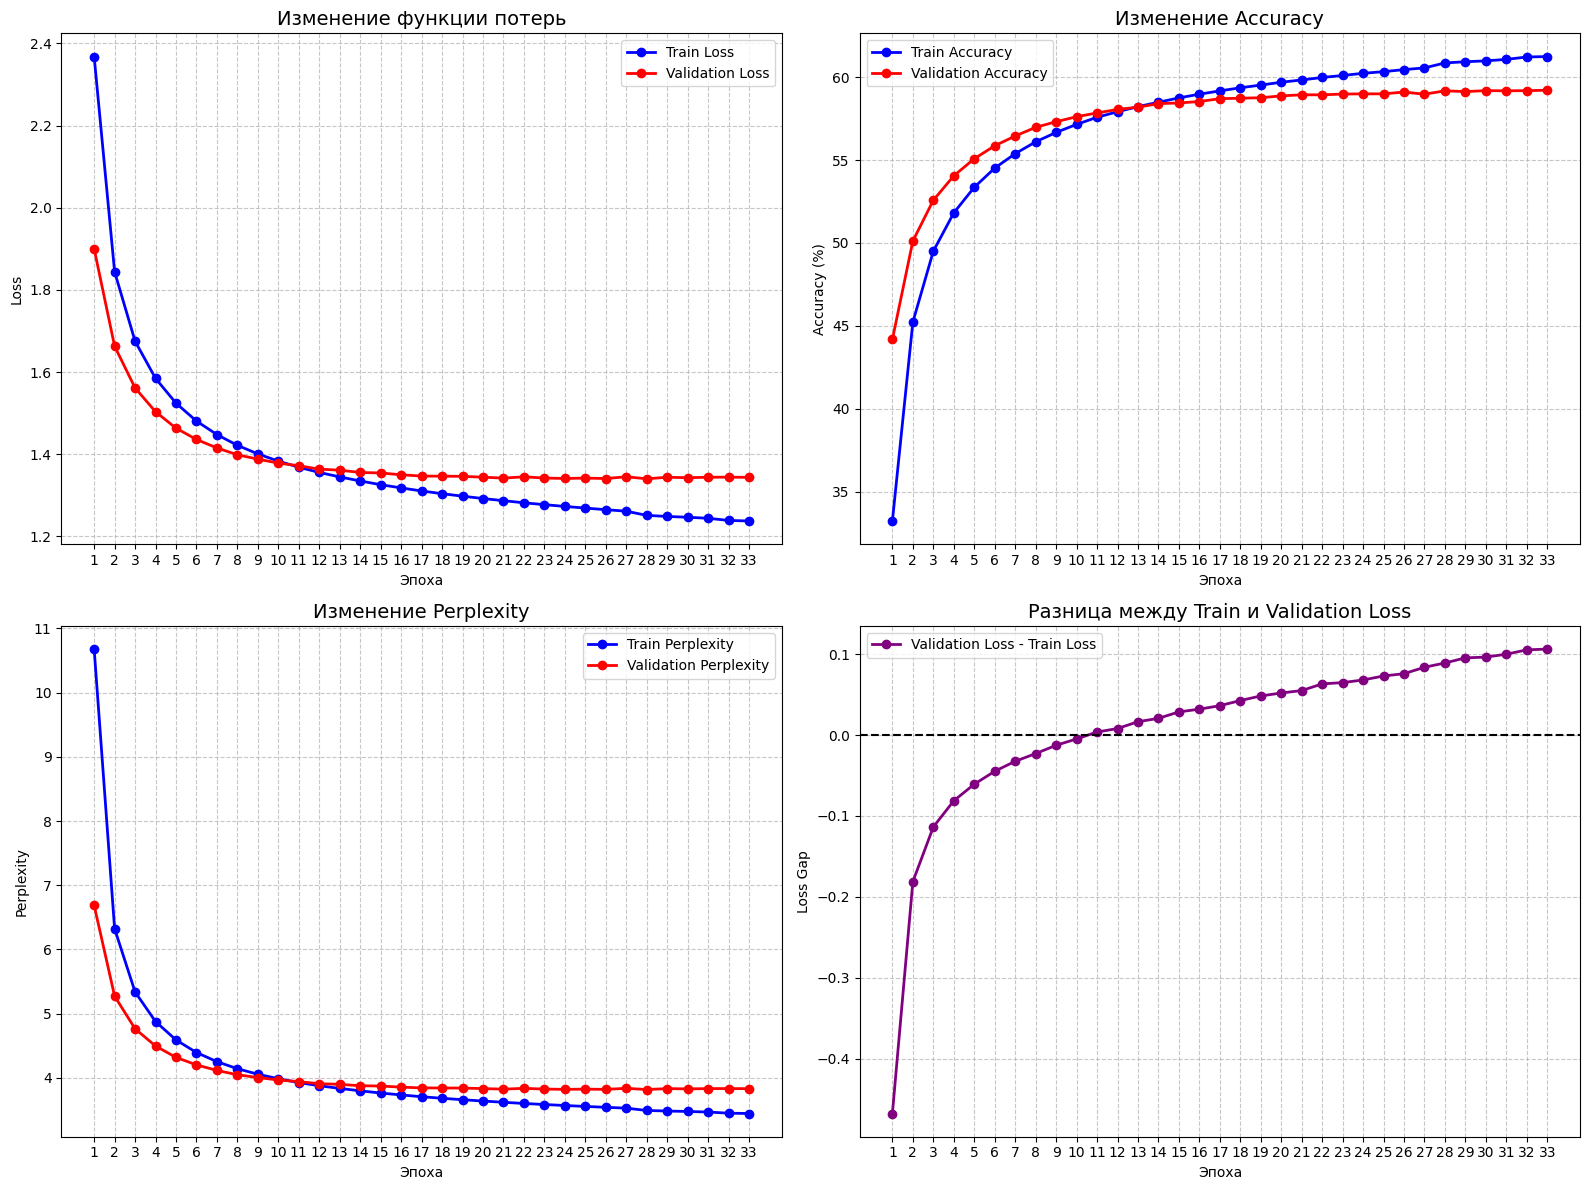

In [9]:
epochs_range = range(1, len(history_train_loss) + 1)

plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
plt.plot(
    epochs_range,
    history_train_loss,
    "b-o",
    linewidth=2,
    label="Train Loss"
)
plt.plot(
    epochs_range,
    history_val_loss,
    "r-o",
    linewidth=2,
    label="Validation Loss"
)
plt.title("Изменение функции потерь", fontsize=14)
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.xticks(epochs_range)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(
    epochs_range,
    history_train_acc,
    "b-o",
    linewidth=2,
    label="Train Accuracy"
)
plt.plot(
    epochs_range,
    history_val_acc,
    "r-o",
    linewidth=2,
    label="Validation Accuracy"
)
plt.title("Изменение Accuracy", fontsize=14)
plt.xlabel("Эпоха")
plt.ylabel("Accuracy (%)")
plt.xticks(epochs_range)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(
    epochs_range,
    history_train_ppl,
    "b-o",
    linewidth=2,
    label="Train Perplexity"
)
plt.plot(
    epochs_range,
    history_val_ppl,
    "r-o",
    linewidth=2,
    label="Validation Perplexity"
)
plt.title("Изменение Perplexity", fontsize=14)
plt.xlabel("Эпоха")
plt.ylabel("Perplexity")
plt.xticks(epochs_range)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

loss_gap = [
    val - train
    for train, val in zip(history_train_loss, history_val_loss)
]

plt.subplot(2, 2, 4)
plt.plot(
    epochs_range,
    loss_gap,
    "purple",
    marker="o",
    linewidth=2,
    label="Validation Loss - Train Loss"
)
plt.axhline(y=0, color="black", linestyle="--")
plt.title("Разница между Train и Validation Loss", fontsize=14)
plt.xlabel("Эпоха")
plt.ylabel("Loss Gap")
plt.xticks(epochs_range)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()


In [10]:
def greedy_search(logits):
    return torch.argmax(logits, dim=-1, keepdim=True)


def random_sample(logits, temperature=1.0):
    if temperature <= 0:
        raise ValueError("Temperature должна быть больше 0")

    logits = logits / temperature
    probs = F.softmax(logits, dim=-1)

    return torch.multinomial(probs, num_samples=1)


def top_k_sample(logits, k=5, temperature=1.0):
    if temperature <= 0:
        raise ValueError("Temperature должна быть больше 0")

    if k <= 0:
        raise ValueError("k должна быть больше 0")

    k = min(k, logits.size(-1))
    logits = logits / temperature

    top_logits, top_indices = torch.topk(logits, k=k, dim=-1)
    probs = F.softmax(top_logits, dim=-1)
    choice_idx = torch.multinomial(probs, num_samples=1)

    return top_indices.gather(-1, choice_idx)


In [11]:
def generate_text(model, prompt, sample_fn, gen_length=250):
    if not prompt:
        raise ValueError("Prompt не может быть пустым")

    unknown_chars = set(prompt) - set(char_to_id.keys())

    if unknown_chars:
        raise ValueError(
            f"В prompt присутствуют неизвестные символы: {unknown_chars}"
        )

    model.eval()
    hidden = None

    input_ids = torch.tensor(
        [[char_to_id[c] for c in prompt]],
        dtype=torch.long
    ).to(device)

    with torch.no_grad():
        logits, hidden = model(input_ids, hidden)

    last_logits = logits[0, -1]
    generated = prompt

    for _ in range(gen_length):
        with torch.no_grad():
            next_id = sample_fn(last_logits)
            next_char = id_to_char[next_id.item()]

            generated += next_char

            input_tensor = next_id.view(1, 1)

            logits, hidden = model(input_tensor, hidden)
            last_logits = logits[0, -1]

    return generated


In [12]:
prompt = "КНЯЗЬ АНДРЕЙ:\n"

print()
print("GREEDY SEARCH")
print(generate_text(model, prompt, greedy_search, gen_length=300))

print()
print("RANDOM SAMPLING | Temperature = 0.7")
print(
    generate_text(
        model,
        prompt,
        partial(random_sample, temperature=0.7),
        gen_length=300
    )
)

print()
print("RANDOM SAMPLING | Temperature = 1.0")
print(
    generate_text(
        model,
        prompt,
        partial(random_sample, temperature=1.0),
        gen_length=300
    )
)

print()
print("TOP-K SAMPLING | k = 3 | Temperature = 0.8")
print(
    generate_text(
        model,
        prompt,
        partial(top_k_sample, k=3, temperature=0.8),
        gen_length=300
    )
)

print()
print("TOP-K SAMPLING | k = 6 | Temperature = 1.0")
print(
    generate_text(
        model,
        prompt,
        partial(top_k_sample, k=6, temperature=1.0),
        gen_length=300
    )
)



GREEDY SEARCH
КНЯЗЬ АНДРЕЙ:
 -- Нет, не могу понять, -- сказал он, -- но не могу понять, что он не мог понять всего в этом состоянии своего собаки, и он не мог понять всего в этом состоянии своей страшное время, которое он не понимал и не понимал и не понимал и не понимал и не понимал и не понимал и не понимал и не понимал и н

RANDOM SAMPLING | Temperature = 0.7
КНЯЗЬ АНДРЕЙ:
 
 Николай испугался в Сони, которому старой офицеров, разговаривавший головы на крайного колкового красного девушки.
 Так выражалось произвольно смотрели в антизманду, которой имел немцат. Он ничего не отвечал, но он не видал и особенно общество. В молодежь и даже она, никогда не убила с веселая пр

RANDOM SAMPLING | Temperature = 1.0
КНЯЗЬ АНДРЕЙ:
 Кирило все было посмеящее слабость, кончившейся щуки отбезенные и своему очень, и самых ни с тости, перевязанные их крыльцо, полагал не повтуская дивана и по сесердом к лицу офицера, с лакею с неестественною и выше направления, как будто испытывали за то, чтобы смея

In [13]:
model_info = {
    "vocab_size": vocabulary_size,
    "embedding_dim": 128,
    "hidden_dim": 256,
    "num_layers": 2,
    "dropout": 0.3,

    "char_to_id": char_to_id,
    "id_to_char": id_to_char
}

torch.save(model_info, "char_rnn_war_and_peace_info.pt")